In [10]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import scipy

In [11]:
plt.style.use("ggplot")

COLOR = "red"
ALPHA_MEAN = 0.9
ALPHA_STD = 0.1
AVG_FILTER_SIZE = 10

In [12]:
BASE = "./checkpoints/"

def load_data(alg: str) -> pd.DataFrame:
    path = os.path.join(BASE, alg)
    dirs = [x for x in os.listdir(path)]

    dfs = [] 
    for dir in dirs:
        path = os.path.join(BASE, alg, dir)
        for file in os.listdir(path):
            if file.endswith(".csv"): 
                path = os.path.join(BASE, alg, dir, file) 
                df = pd.read_csv(path)
                dfs.append(df)

    df_out = pd.DataFrame() 
    df_out["timesteps"] = dfs[0]["timesteps"]

    stacked_means = pd.concat([df["average_return"] for df in dfs], axis=1)
    stacked_speeds = pd.concat([df["average_speed"] for df in dfs], axis=1)
    df_out["average_return"] = stacked_means.mean(axis=1)  
    df_out["average_speed"] = stacked_speeds.mean(axis=1)  
    df_out["std_return"] = stacked_means.std(axis=1, ddof=1)  


    return df_out

In [13]:
data = load_data("ddpg")
data.head()

,timesteps,average_return,average_speed,std_return
0,5000,-1.033253,0.000000,0.028882
1,10000,-1.062053,0.095725,0.056213
2,15000,-1.102469,0.000000,0.136182
3,20000,-1.187379,0.000000,0.248042
4,25000,-1.164594,0.000000,0.139747


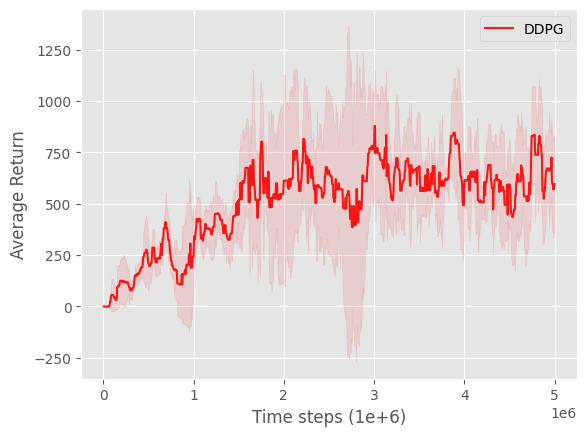

In [14]:
t = data["timesteps"]
# mean = data["average_return"]
mean = scipy.ndimage.median_filter(data["average_return"], size=AVG_FILTER_SIZE)

# std = data["std_return"]
std = scipy.ndimage.median_filter(data["std_return"], size=AVG_FILTER_SIZE)

lower = mean - std
upper = mean + std

fig, ax = plt.subplots()
ax.plot(t, mean, color=COLOR, alpha=ALPHA_MEAN, label="DDPG")
ax.fill_between(t, lower, upper, alpha=ALPHA_STD, color=COLOR)
ax.set_xlabel("Time steps (1e+6)")
ax.set_ylabel("Average Return")
ax.legend()
plt.show()

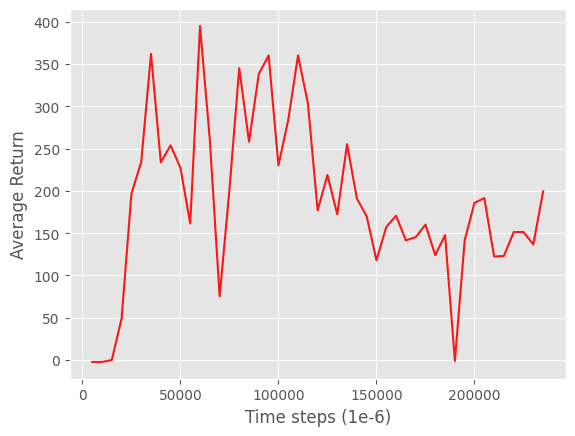

In [15]:
data = load_data("td3")
data.head()

t = data["timesteps"]
mean = data["average_return"]
# mean = scipy.ndimage.median_filter(data["average_return"], size=AVG_FILTER_SIZE)
std = data["std_return"]
lower = mean - std
upper = mean + std

fig, ax = plt.subplots()
ax.plot(t, mean, color=COLOR, alpha=ALPHA_MEAN)
ax.fill_between(t, lower, upper, alpha=ALPHA_STD, color=COLOR)
ax.set_xlabel("Time steps (1e-6)")
ax.set_ylabel("Average Return")
plt.show()

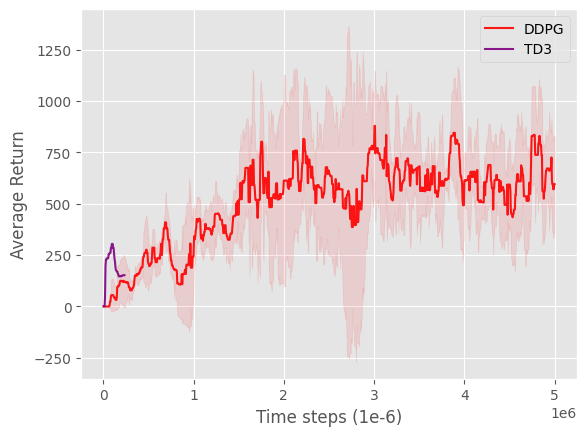

In [16]:
fig, ax = plt.subplots()


colors = {"ddpg": "red", "td3": "purple"}
algorithms = {"ddpg": "DDPG", "td3": "TD3"}

for alg in ["ddpg", "td3"]:
    data = load_data(alg)

    t = data["timesteps"]
    mean = data["average_return"]
    mean = scipy.ndimage.median_filter(data["average_return"], size=AVG_FILTER_SIZE)
    std = scipy.ndimage.median_filter(data["std_return"], size=AVG_FILTER_SIZE)
    # std = data["std_return"]
    lower = mean - std
    upper = mean + std

    ax.plot(t, mean, color=colors[alg], alpha=ALPHA_MEAN, label=algorithms[alg])
    ax.fill_between(t, lower, upper, alpha=ALPHA_STD, color=colors[alg])
    ax.set_xlabel("Time steps (1e-6)")
    ax.set_ylabel("Average Return")
    ax.legend()

plt.show()

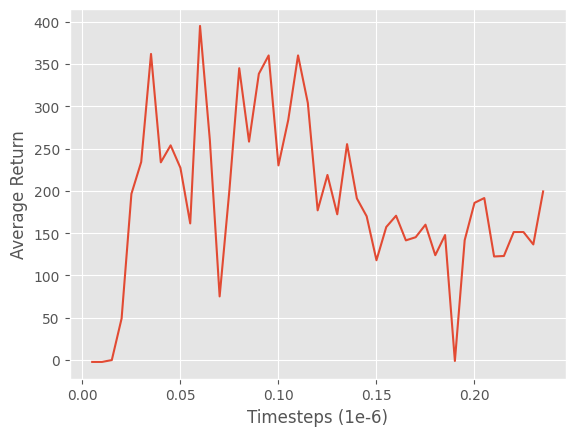

In [17]:
csv_file = f"checkpoints/td3/td3-lr_pi0.001-lr_q0.001-seed0/eval_stats.csv"
data = pd.read_csv(csv_file)
data["timesteps"] /= 1_000_000

fig, ax = plt.subplots()
ax.plot(data["timesteps"], data["average_return"])
ax.set_xlabel("Timesteps (1e-6)")
ax.set_ylabel("Average Return")
plt.show()

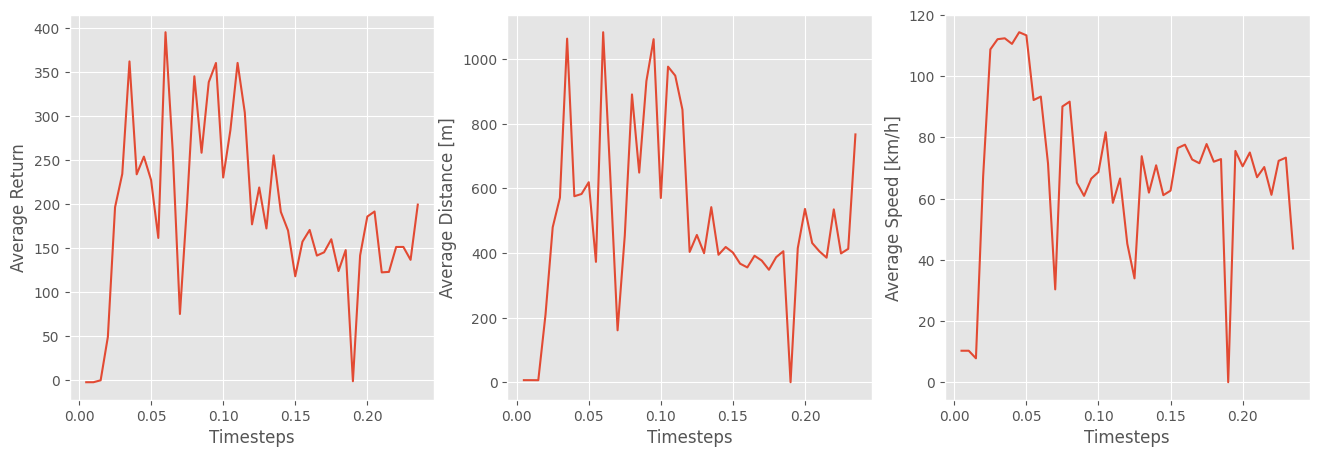

: 

In [ ]:
fig, axes = plt.subplots(ncols=3, figsize=(16, 5))
axes = axes.flatten()

columns = ["average_return", "average_distance", "average_speed"]
col_to_unit = {"average_return": "Average Return", "average_distance": "Average Distance [m]", "average_speed": "Average Speed [km/h]"}

for ax, col in zip(axes, columns):
    ax.plot(data["timesteps"], data[col])
    ax.set_xlabel("Timesteps")
    ax.set_ylabel(col_to_unit[col])

plt.show()